# ORCESTRA Campaign: Kinematic Profiling of Tropical Convection
**Dataset:** Level-4 HALO Aircraft Dropsonde Circle Products (EC-TOOC / ORCESTRA)  
**Objective:** To categorize mesoscale vertical velocity ($\omega$) profiles.

### Scientific Framework
Following Johnson et al. (1999) and Back & Bretherton (2006), the flight circles are classified based on the magnitude and pressure level of maximum macroscopic ascent (minimum $\omega$):
* **Suppressed / Weak:** No significant ascent (minimum $\omega > -0.05$ Pa/s).
* **Top-Heavy (Deep):** Peak ascent occurs above the freezing level (**500 hPa**).
* **Bottom-Heavy (Congestus):** Peak ascent occurs between **800 hPa** and **500 hPa**.
* **Shallow:** Peak ascent is trapped below the trade inversion (**800 hPa**).

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
import os

# Load your ORCESTRA Level-4 dataset
# (Replace the path below with the actual location of your data file)
# 1. SETUP & LOAD DATA
os.environ["IPFS_GATEWAY"] = "https://ipfs.io"
data_url = "ipfs://bafybeihfqxfckruepjhrkafaz6xg5a4sepx6ahhv4zds4b3hnfiyj35c5i"
print(f"Attempting to access data from: {data_url}")

try:
    ds = xr.open_dataset(data_url, engine="zarr")
    print("Dataset successfully loaded!\n")
except Exception as e:
    print(f"Error loading dataset: {e}")

Attempting to access data from: ipfs://bafybeihfqxfckruepjhrkafaz6xg5a4sepx6ahhv4zds4b3hnfiyj35c5i
Dataset successfully loaded!



### Step 1: Categorization Algorithm
This algorithm loops through every individual flight circle. It finds the strongest upward motion (the minimum $\omega$ value) and checks the pressure level (`p_mean`) where it occurs to assign the correct convective regime.

In [42]:
# ==========================================
# VERSION 1: TRIMODAL CATEGORIZATION
# ==========================================

categories_trimodal = []

for c in ds.circle.values:
    omega_profile = ds['omega'].sel(circle=c)
    p_profile = ds['p_mean'].sel(circle=c) / 100 # Convert Pa to hPa
    
    # Handle missing data
    if np.isnan(omega_profile).all():
        categories_trimodal.append("Missing Data")
        continue
        
    min_omega = omega_profile.min().values
    
    # Criterion 1: Intensity
    if min_omega > -0.05:
        categories_trimodal.append("Suppressed / Weak")
    else:
        # Criterion 2: Altitude of peak ascent (Trimodal)
        idx_min = omega_profile.argmin().values
        p_peak = p_profile.isel(altitude=idx_min).values
        
        if p_peak < 500:
            categories_trimodal.append("Top-Heavy (Deep)")
        elif p_peak < 800:
            categories_trimodal.append("Bottom-Heavy (Congestus)")
        else:
            categories_trimodal.append("Shallow")

# Save as a specific trimodal variable so we don't overwrite things
ds['category_trimodal'] = (('circle'), categories_trimodal)

# For compatibility with your existing plotting code, we can temporarily set 'category'
ds['category'] = ds['category_trimodal']
ds_categorized = ds

print("TRIMODAL Categorization complete. Breakdown:")
print(pd.Series(categories_trimodal).value_counts())

/g/data/k10/zr7147/orcestra_env/lib/python3.12/site-packages/xarray/core/dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/g/data/k10/zr7147/orcestra_env/lib/python3.12/site-packages/xarray/core/dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/g/data/k10/zr7147/orcestra_env/lib/python3.12/site-packages/xarray/core/dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will chan

TRIMODAL Categorization complete. Breakdown:
Top-Heavy (Deep)            29
Suppressed / Weak           22
Bottom-Heavy (Congestus)    22
Shallow                     14
Missing Data                 2
Name: count, dtype: int64


/g/data/k10/zr7147/orcestra_env/lib/python3.12/site-packages/xarray/core/dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


In [43]:
# ==========================================
# VERSION 2: BIMODAL CATEGORIZATION
# ==========================================
import numpy as np
import pandas as pd

categories_bimodal = []

for c in ds.circle.values:
    omega_profile = ds['omega'].sel(circle=c)
    p_profile = ds['p_mean'].sel(circle=c) / 100 # Convert Pa to hPa
    
    # Handle missing data
    if np.isnan(omega_profile).all():
        categories_bimodal.append("Missing Data")
        continue
        
    min_omega = omega_profile.min().values
    
    # Criterion 1: Intensity (Remains the same)
    if min_omega > -0.05:
        categories_bimodal.append("Suppressed / Weak")
    else:
        # Criterion 2: Altitude of peak ascent (Bimodal split at 500 hPa)
        idx_min = omega_profile.argmin().values
        p_peak = p_profile.isel(altitude=idx_min).values
        
        if p_peak < 500:
            categories_bimodal.append("Deep (Top-Heavy)")
        else:
            # Combines the Congestus and Shallow into one lower-level category
            categories_bimodal.append("Shallow (Bottom-Heavy)")

# Save as a specific bimodal variable
ds['category_bimodal'] = (('circle'), categories_bimodal)

# OVERWRITE the main 'category' variable so your existing plotting code uses THIS version instead
ds['category'] = ds['category_bimodal']
ds_categorized = ds

print("BIMODAL Categorization complete. Breakdown:")
print(pd.Series(categories_bimodal).value_counts())

/g/data/k10/zr7147/orcestra_env/lib/python3.12/site-packages/xarray/core/dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/g/data/k10/zr7147/orcestra_env/lib/python3.12/site-packages/xarray/core/dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/g/data/k10/zr7147/orcestra_env/lib/python3.12/site-packages/xarray/core/dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will chan

BIMODAL Categorization complete. Breakdown:
Shallow (Bottom-Heavy)    36
Deep (Top-Heavy)          29
Suppressed / Weak         22
Missing Data               2
Name: count, dtype: int64


/g/data/k10/zr7147/orcestra_env/lib/python3.12/site-packages/xarray/core/dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


In [44]:
ds

<xarray.Dataset> Size: 116MB
Dimensions:                   (circle: 89, altitude: 1460, sonde: 1058)
Coordinates:
    circle_lat                (circle) float32 356B ...
    circle_lon                (circle) float32 356B ...
    circle_time               (circle) datetime64[ns] 712B ...
    sondes_per_circle         (circle) int64 712B ...
  * altitude                  (altitude) float64 12kB 0.0 10.0 ... 1.459e+04
    launch_time               (sonde) datetime64[ns] 8kB ...
Dimensions without coordinates: circle, sonde
Data variables: (12/76)
    circle_altitude           (circle) float32 356B ...
    circle_id                 (circle) <U19 7kB ...
    circle_radius             (circle) float32 356B ...
    div                       (circle, altitude) float32 520kB ...
    div_sonde_relevance       (sonde, altitude) float32 6MB ...
    div_std_error             (circle, altitude) float32 520kB ...
    ...                        ...
    wvel_std_error            (circle, altitude) float32 520kB ...
    x                         (sonde, altitude) float32 6MB ...
    y                         (sonde, altitude) float32 6MB ...
    category_trimodal         (circle) <U24 9kB 'Top-Heavy (Deep)' ... 'Top-H...
    category                  (circle) <U22 8kB 'Deep (Top-Heavy)' ... 'Deep ...
    category_bimodal          (circle) <U22 8kB 'Deep (Top-Heavy)' ... 'Deep ...
Attributes:
    creator_email:  helene.gloeckner@mpimet.mpg.de, theresa.mieslinger@mpimet...
    creator_name:   Helene Gloeckner, Theresa Mieslinger, Nina Robbins
    featureType:    trajectoryProfile
    history:        Level 1 ASPEN processing with Aspen V4.0.4 \nLevel 2 qual...
    keywords:       ORCESTRA, BEACH, Sounding, Dropsondes, Tropics, Atmospher...
    license:        CC-BY-4.0
    platform:       HALO
    project:        ORCESTRA, PERCUSION, MAESTRO
    references:     https://github.com/atmdrops/pydropsonde
    source:         dropsondes
    summary:        This dataset is the Level 4 BEACH dataset. It contains on...
    title:          BEACH dropsonde dataset (Level 4)

### Check Data Availability

In [45]:
import pandas as pd

print("--- Missing Data Report ---")
missing_found = False

# Loop through all circles
for c in ds_categorized.circle.values:
    # Get the category for this specific circle
    cat = str(ds_categorized.category_bimodal.sel(circle=c).values)
    
    # Check if it's missing
    if cat == "Missing Data":
        raw_time = ds_categorized['circle_time'].sel(circle=c).values
        dt_str = pd.Timestamp(raw_time).strftime('%Y-%m-%d %H:%M')
        
        print(f"Circle {c} | Date/Time: {dt_str}")
        missing_found = True

if not missing_found:
    print("Great news: No missing data found in any circle! The dataset is clean.")

--- Missing Data Report ---
Circle 30 | Date/Time: 2024-08-27 17:59
Circle 54 | Date/Time: 2024-09-14 13:12


### Step 2: Visualization of Vertical Profiles
For each identified regime, we generate two visualizations:
1. **Spaghetti Plot:** Overlays all profiles within a category alongside the ensemble mean.
2. **Individual Grid:** Displays each profile separately, labeled with its exact flight time (UTC) to highlight that multiple distinct atmospheric states are often sampled within a single day.


GENERATING AND SAVING PLOTS FOR REGIME: DEEP (TOP-HEAVY) (29 circles)

Saved: /home/565/zr7147/Proj/Plot-Figs/Bimodal_Spaghetti_Deep_Top-Heavy.png


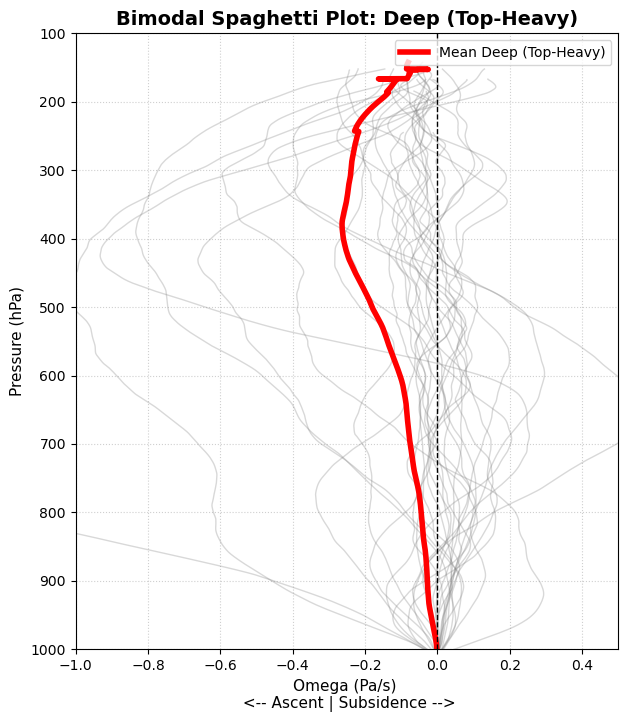

Saved: /home/565/zr7147/Proj/Plot-Figs/Bimodal_Grid_Deep_Top-Heavy.png


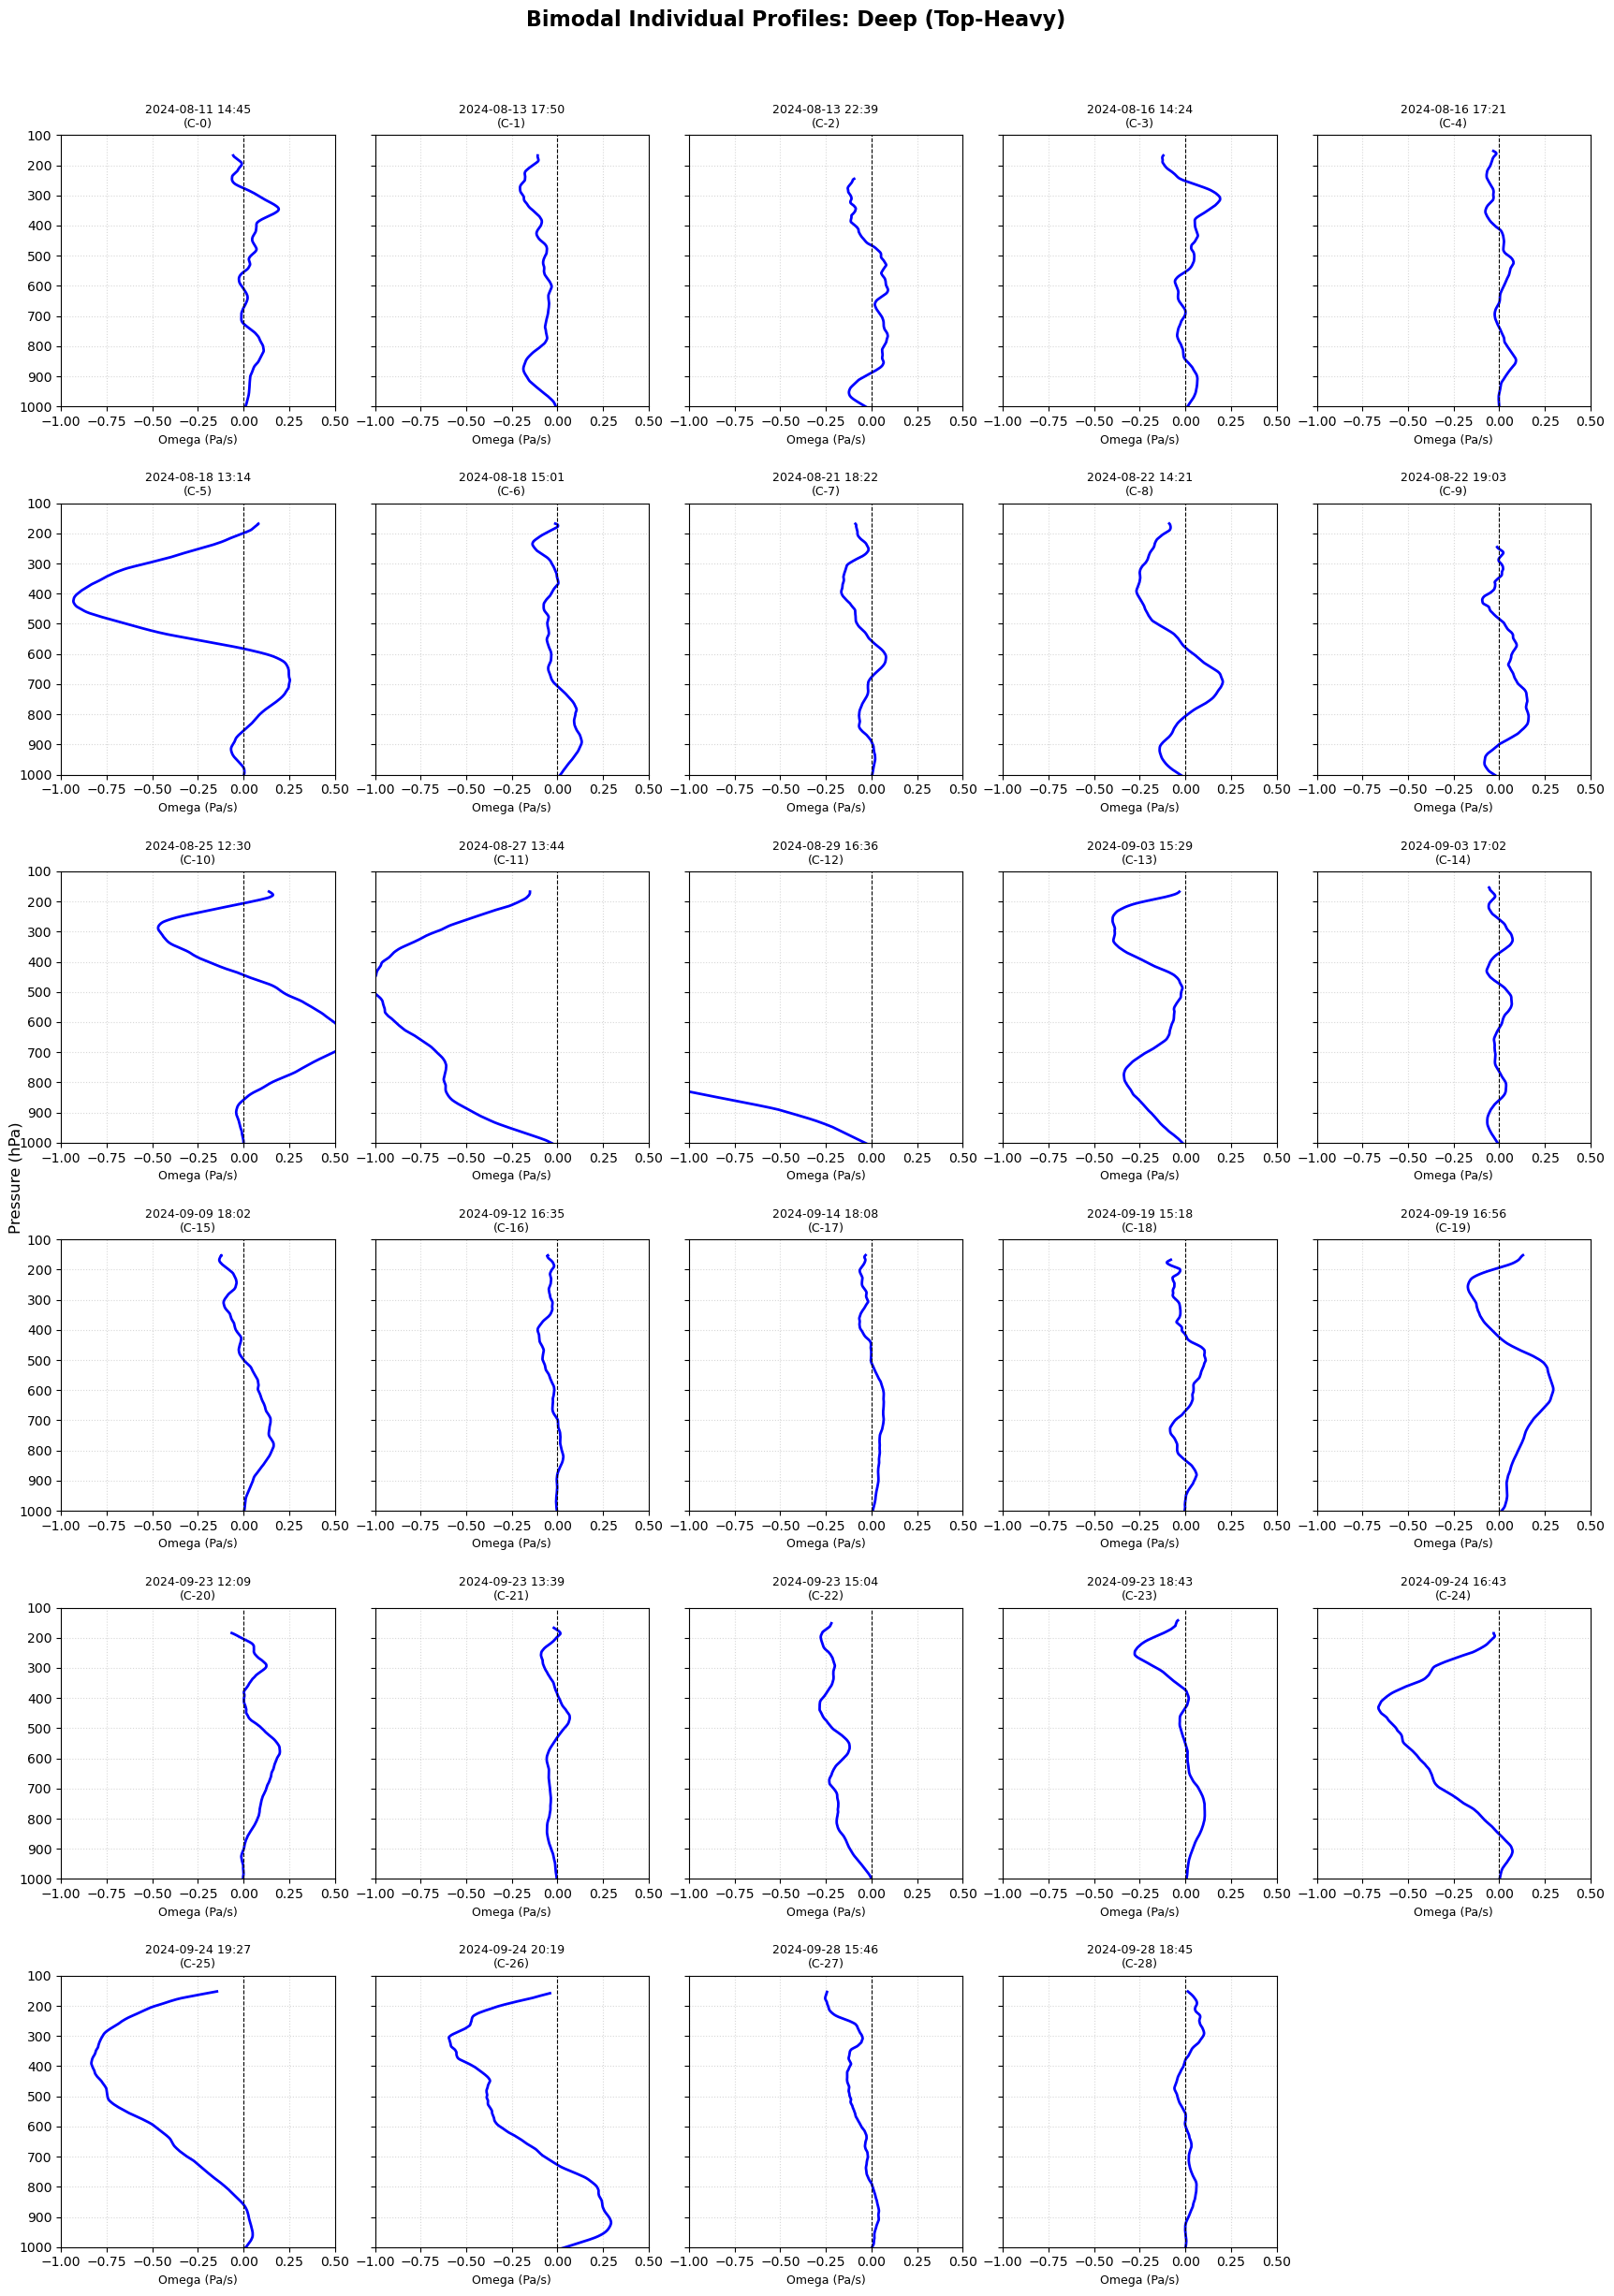


GENERATING AND SAVING PLOTS FOR REGIME: SHALLOW (BOTTOM-HEAVY) (36 circles)

Saved: /home/565/zr7147/Proj/Plot-Figs/Bimodal_Spaghetti_Shallow_Bottom-Heavy.png


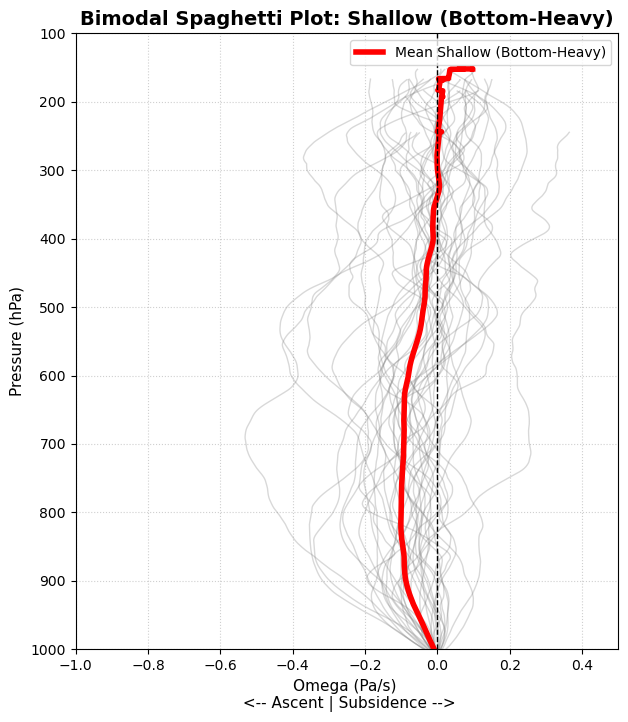

Saved: /home/565/zr7147/Proj/Plot-Figs/Bimodal_Grid_Shallow_Bottom-Heavy.png


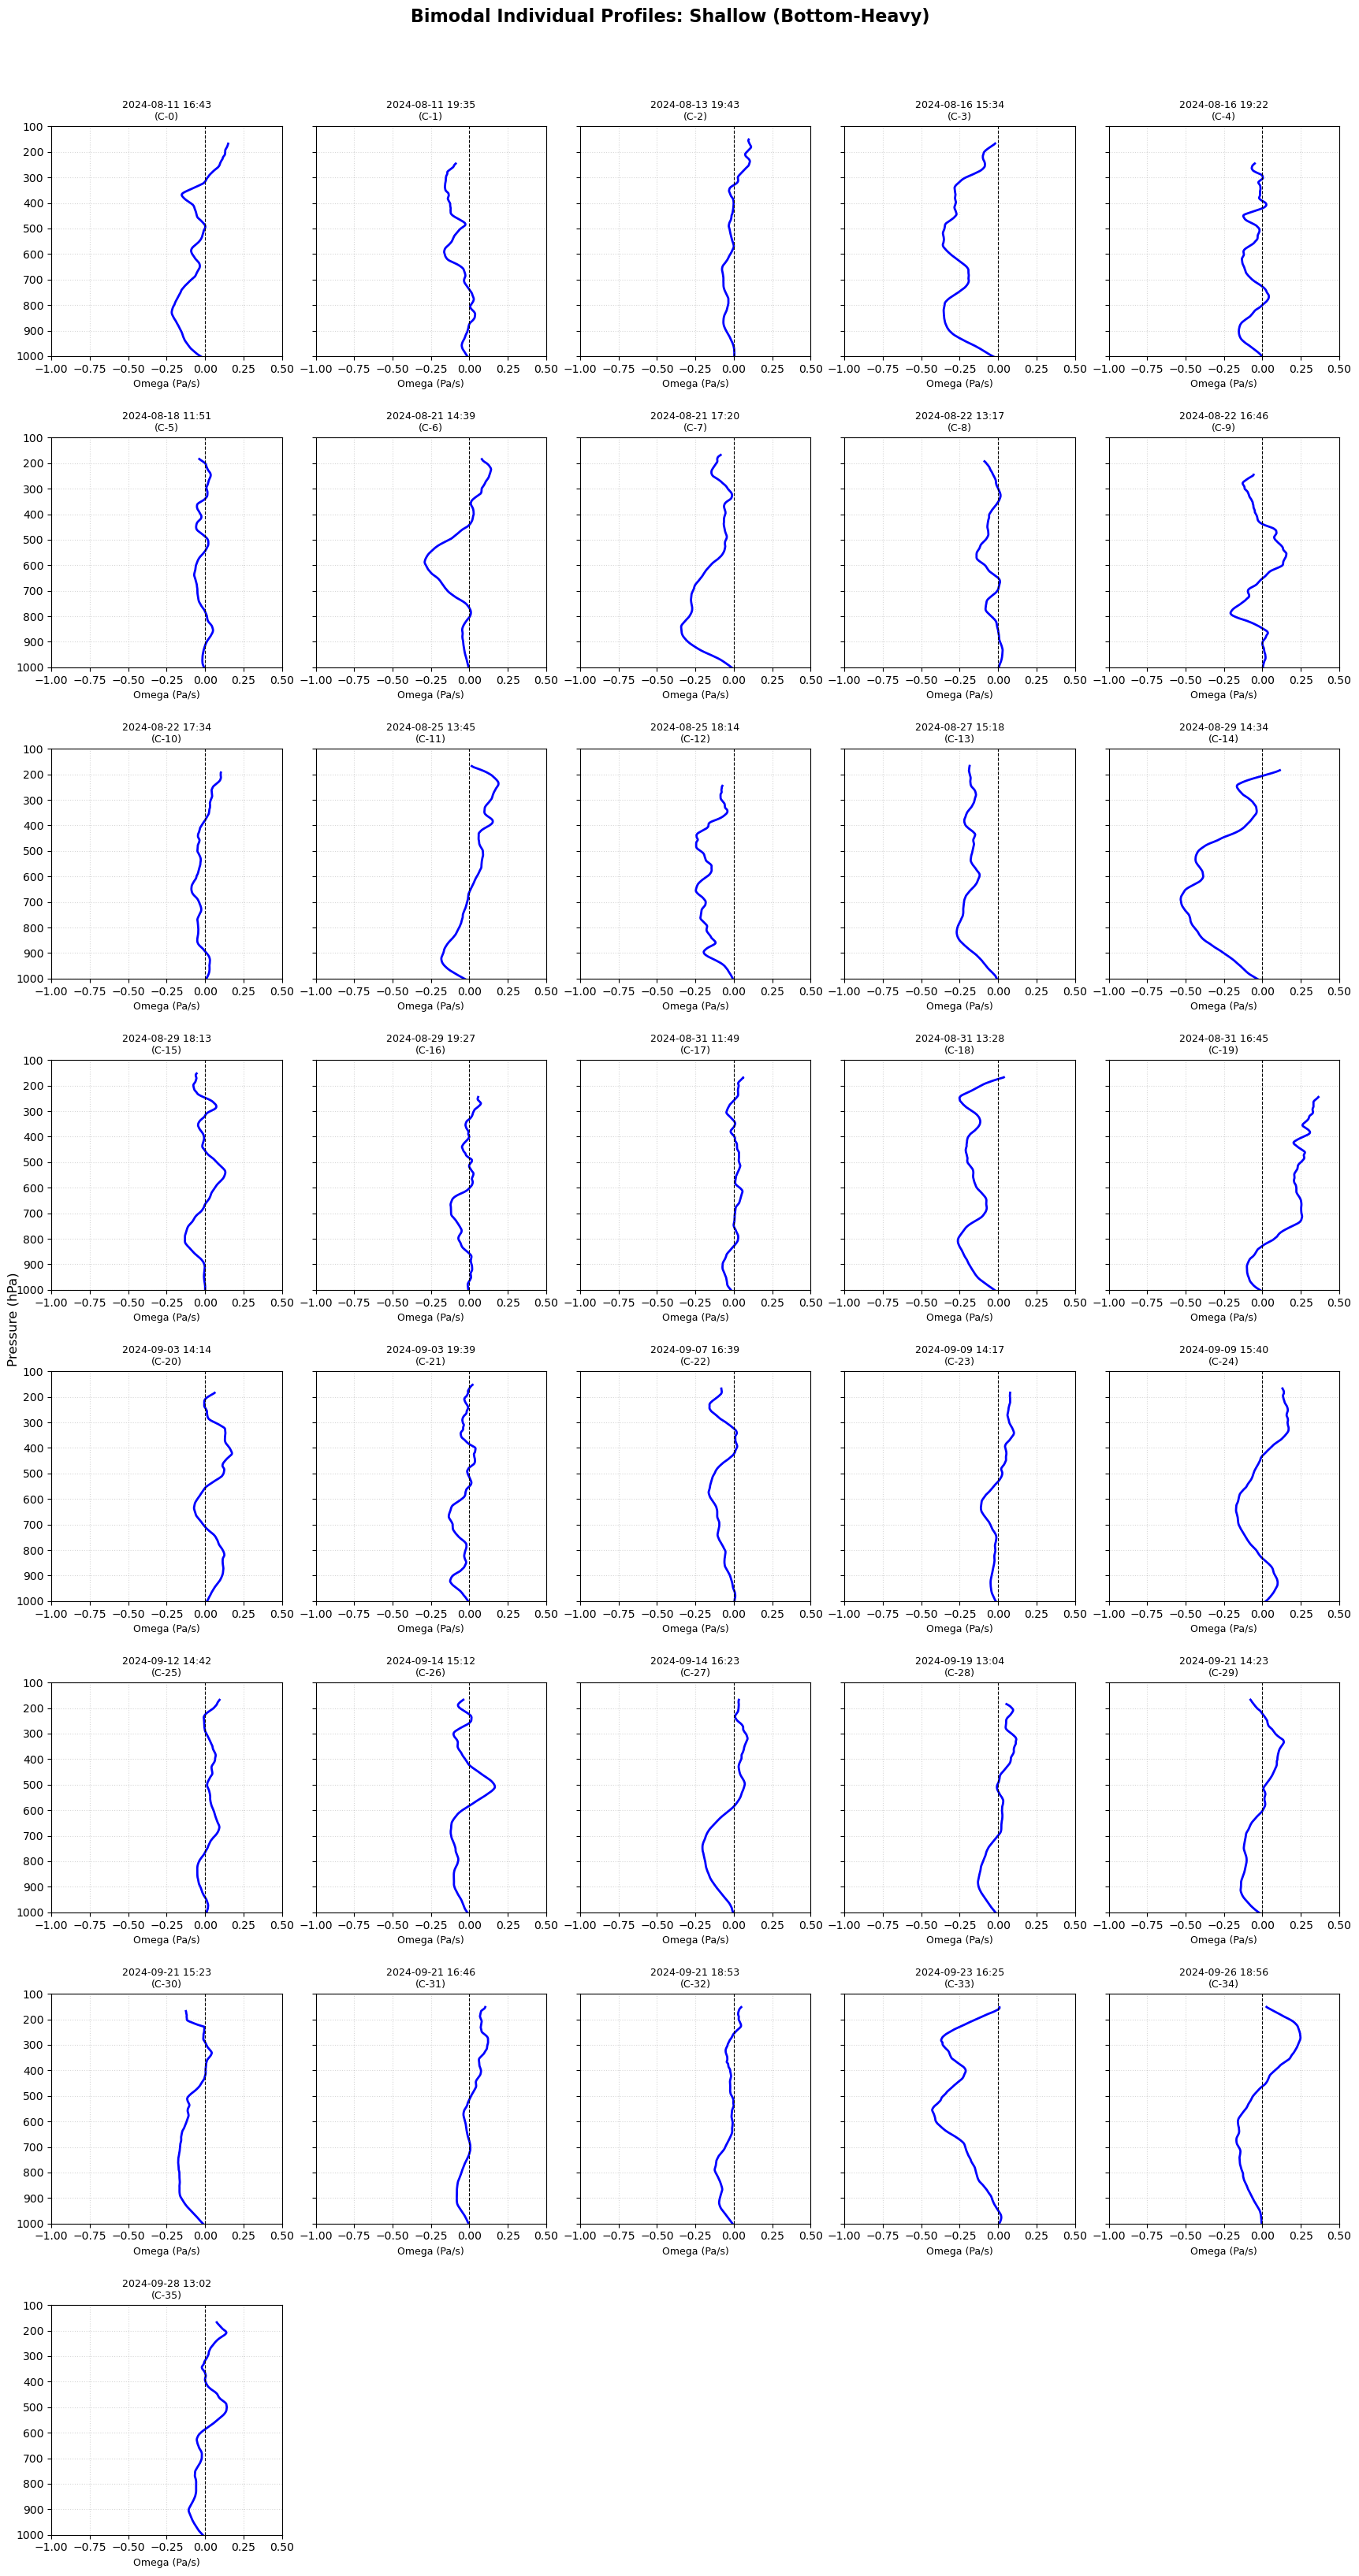


GENERATING AND SAVING PLOTS FOR REGIME: SUPPRESSED / WEAK (22 circles)

Saved: /home/565/zr7147/Proj/Plot-Figs/Bimodal_Spaghetti_Suppressed_Weak.png


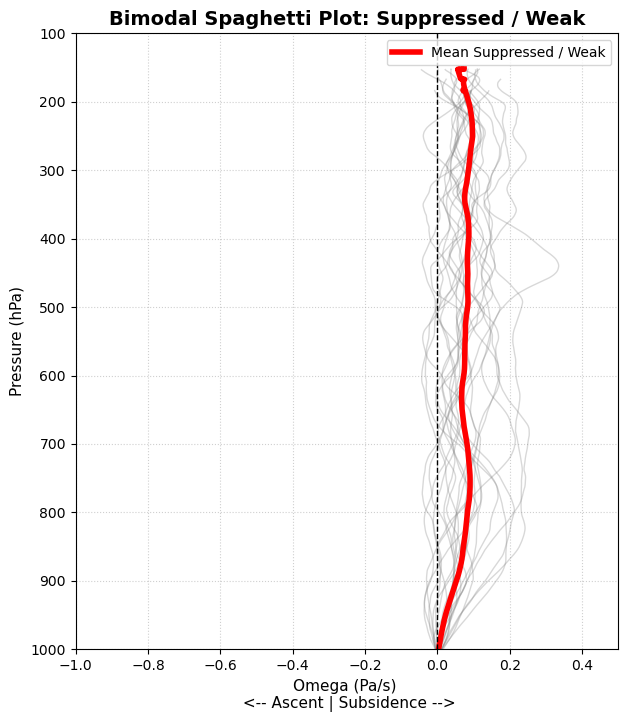

Saved: /home/565/zr7147/Proj/Plot-Figs/Bimodal_Grid_Suppressed_Weak.png


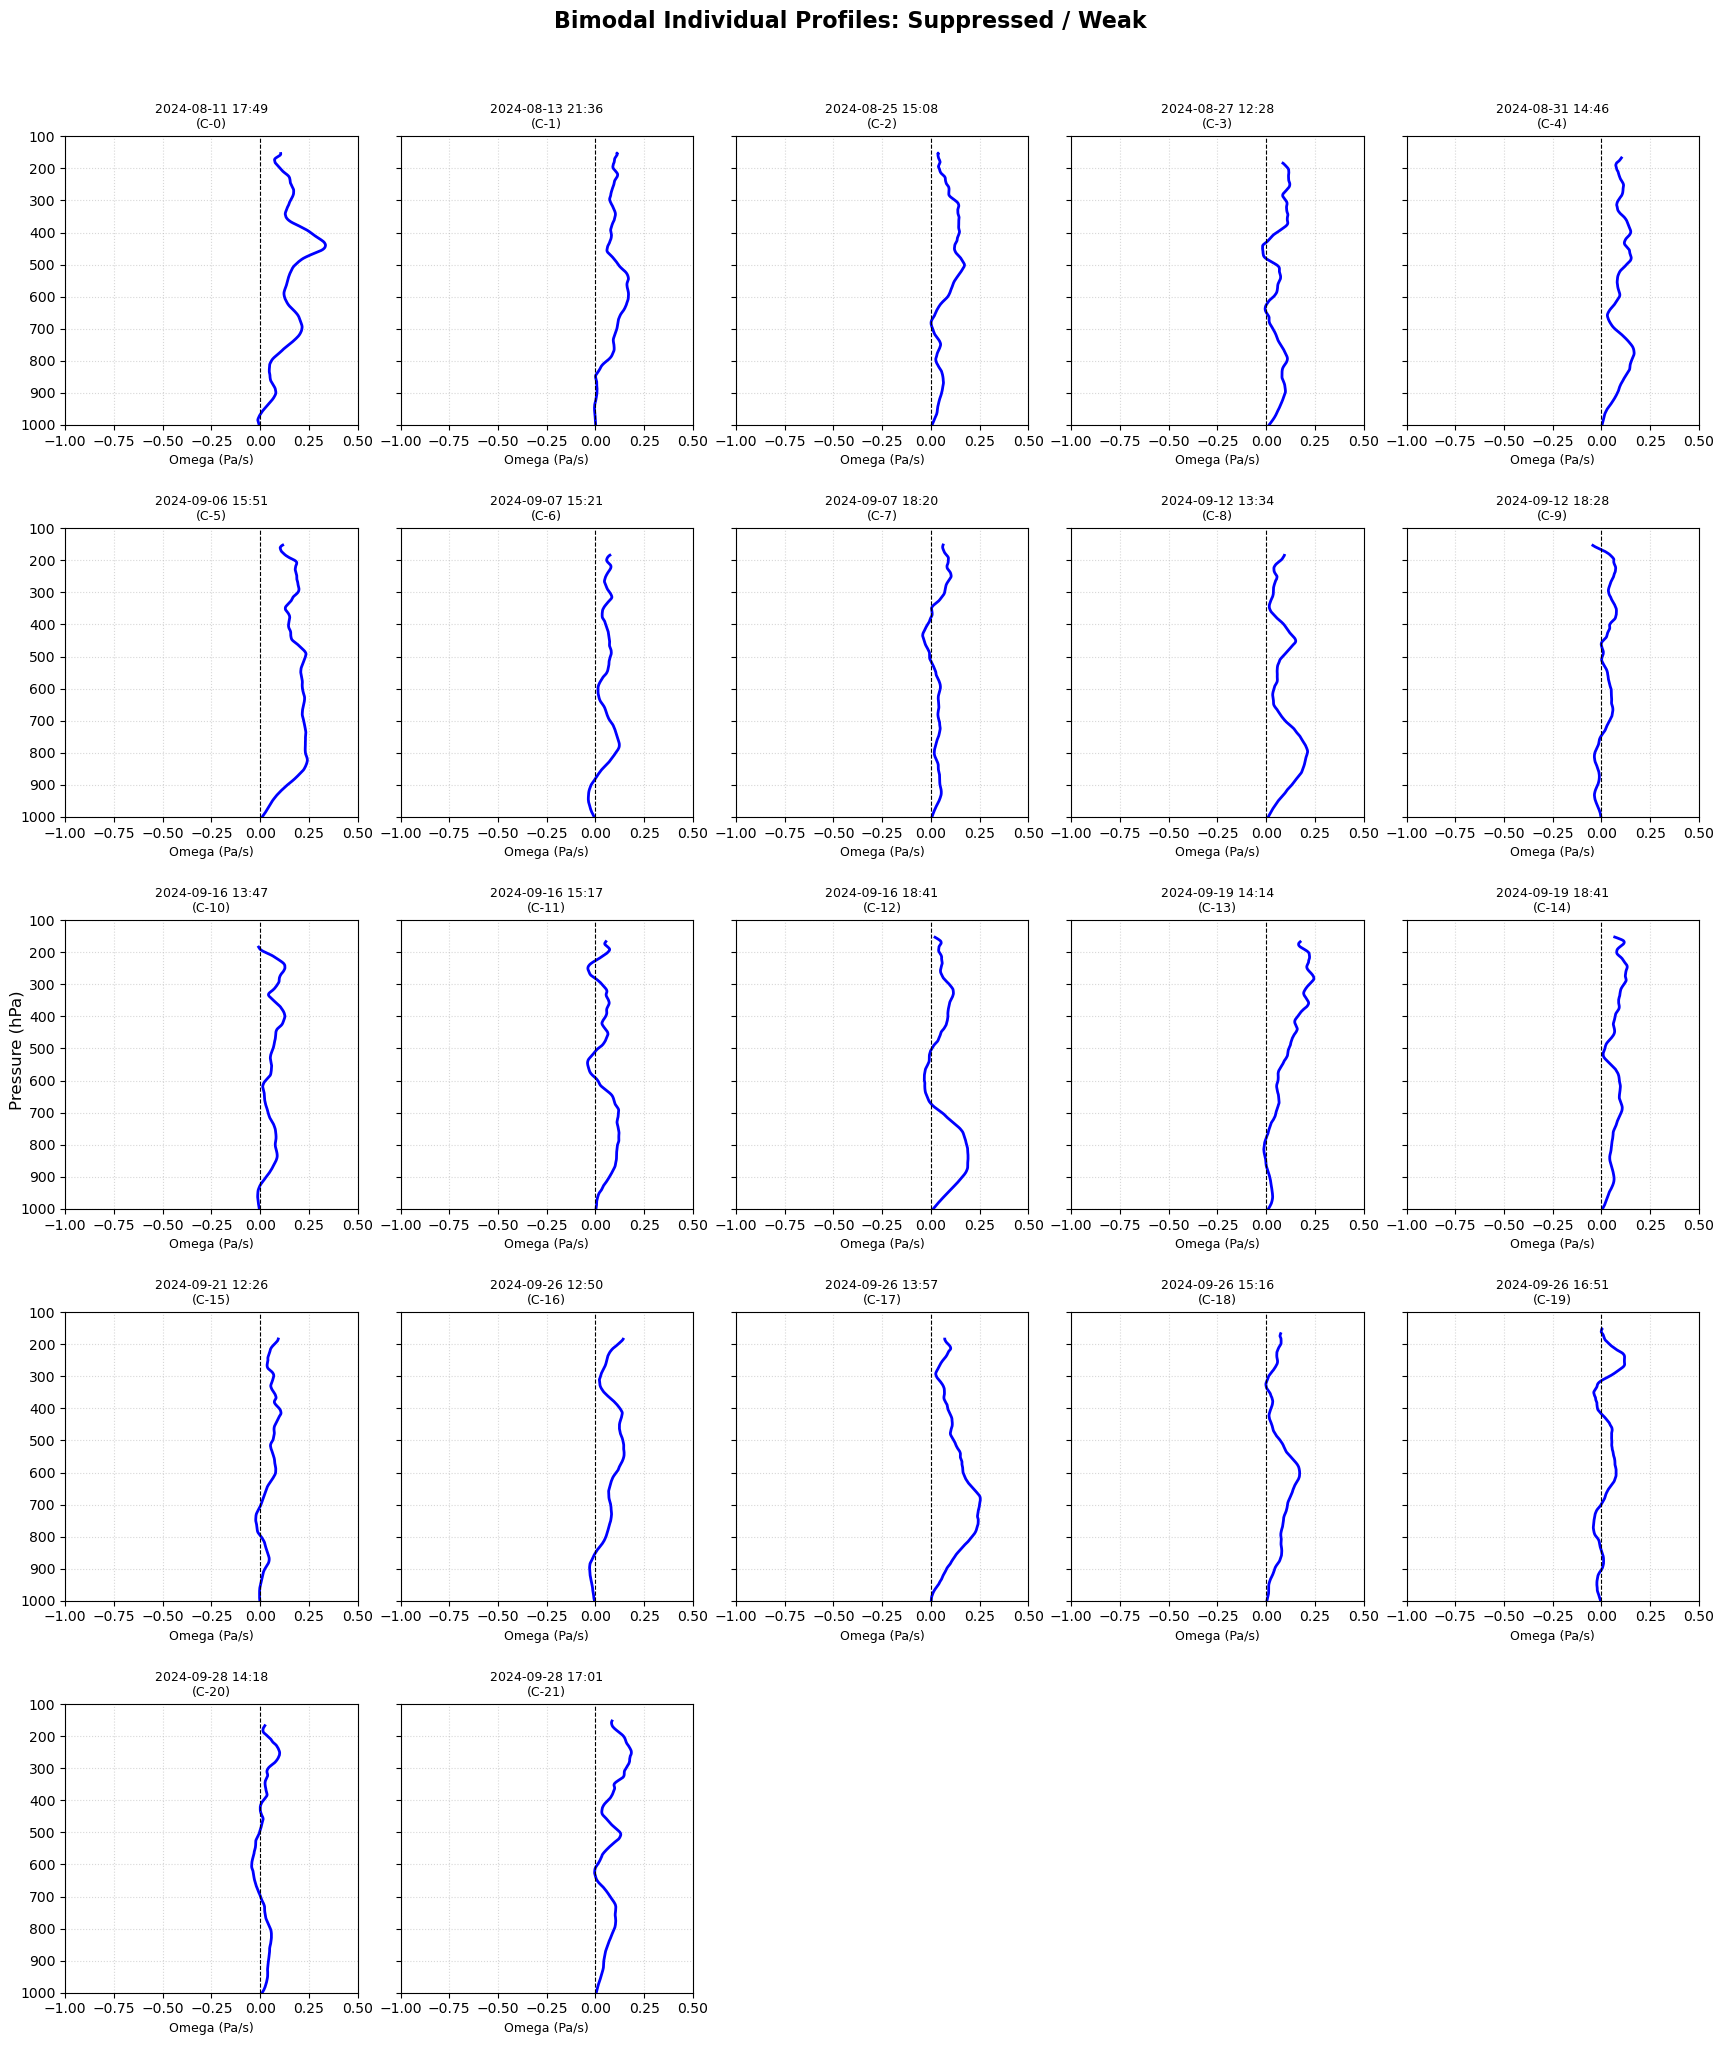

In [56]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define your exact Gadi output directory
output_dir = "/home/565/zr7147/Proj/Plot-Figs"
os.makedirs(output_dir, exist_ok=True) 

# ---------------------------------------------------------
# 2. SELECT CATEGORIZATION MODE (TOGGLE HERE)
# ---------------------------------------------------------
# --- DEFAULT: TRIMODAL MAPPING ---
# mode_prefix = "Trimodal"
# category_var = "category_trimodal" 

# --- ALTERNATIVE: BIMODAL MAPPING ---
# To use this, comment out the two lines above, and uncomment the two lines below!
mode_prefix = "Bimodal"
category_var = "category_bimodal"


# Get a list of unique categories using your selected toggle, skipping "Missing Data"
valid_categories = [cat for cat in np.unique(ds_categorized[category_var].values) if cat != "Missing Data"]

# Define consistent axes limits for fair comparison
x_limits = (-1.0, 0.5)
y_limits = (1000, 100) # Pressure in hPa. Matplotlib will automatically invert this!

# Loop through each category
for cat in valid_categories:
    
    # Create a safe filename by removing spaces, slashes, and parentheses
    safe_cat_name = cat.replace(" / ", "_").replace(" ", "_").replace("(", "").replace(")", "")
    
    # Filter data for this specific category using the toggled variable
    cat_mask = ds_categorized[category_var] == cat
    ds_cat = ds_categorized.isel(circle=cat_mask)
    
    circle_indices = ds_cat.circle.values
    n_circles = len(circle_indices)
    
    print(f"\n{'='*60}")
    print(f"GENERATING AND SAVING PLOTS FOR REGIME: {cat.upper()} ({n_circles} circles)")
    print(f"{'='*60}\n")
    
    # ---------------------------------------------------------
    # PLOT TYPE 1: THE "SPAGHETTI" PLOT
    # ---------------------------------------------------------
    fig1, ax1 = plt.subplots(figsize=(7, 8))
    
    for c in circle_indices:
        profile = ds_cat['omega'].sel(circle=c)
        pressure = ds_cat['p_mean'].sel(circle=c) / 100 # Convert Pa to hPa
        ax1.plot(profile, pressure, color='gray', alpha=0.3, linewidth=1)
        
    mean_profile = ds_cat['omega'].mean(dim='circle')
    mean_pressure = ds_cat['p_mean'].mean(dim='circle') / 100
    
    ax1.plot(mean_profile, mean_pressure, color='red', linewidth=4, label=f'Mean {cat}')
    
    ax1.axvline(0, color='black', linestyle='--', linewidth=1)
    ax1.set_xlim(x_limits)
    ax1.set_ylim(y_limits) 
    
    ax1.set_xlabel('Omega (Pa/s) \n <-- Ascent | Subsidence -->', fontsize=11)
    ax1.set_ylabel('Pressure (hPa)', fontsize=11)
    ax1.set_title(f'{mode_prefix} Spaghetti Plot: {cat}', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    # NEW: Save Spaghetti Plot with Mode Prefix
    fig1_path = os.path.join(output_dir, f'{mode_prefix}_Spaghetti_{safe_cat_name}.png')
    fig1.savefig(fig1_path, dpi=300, bbox_inches='tight') 
    print(f"Saved: {fig1_path}")
    
    plt.show()
    
    # ---------------------------------------------------------
    # PLOT TYPE 2: THE INDIVIDUAL GRID PLOTS
    # ---------------------------------------------------------
    cols = 5
    rows = math.ceil(n_circles / cols)
    
    fig2, axes = plt.subplots(rows, cols, figsize=(cols*3.5, rows*4), sharex=True, sharey=True)
    axes = axes.flatten()
    
    for i, c in enumerate(circle_indices):
        profile = ds_cat['omega'].sel(circle=c)
        pressure = ds_cat['p_mean'].sel(circle=c) / 100
        
        # Extract Exact Date and Time
        raw_time = ds_cat['circle_time'].sel(circle=c).values
        datetime_str = pd.Timestamp(raw_time).strftime('%Y-%m-%d %H:%M')
        
        axes[i].plot(profile, pressure, color='blue', linewidth=2)
        axes[i].axvline(0, color='black', linestyle='--', linewidth=0.8)
        
        axes[i].set_title(f'{datetime_str}\n(C-{c})', fontsize=9) 
        axes[i].grid(True, linestyle=':', alpha=0.5)
        
        # Force X-labels to appear on every single chart in the grid
        axes[i].tick_params(labelbottom=True) 
        axes[i].set_xlabel('Omega (Pa/s)', fontsize=9)
        
    # Hide any extra empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    axes[0].set_xlim(x_limits)
    axes[0].set_ylim(y_limits)
    
    fig2.suptitle(f'{mode_prefix} Individual Profiles: {cat}', fontsize=16, fontweight='bold', y=1.02)
    fig2.supylabel('Pressure (hPa)', fontsize=12)
    
    plt.tight_layout(h_pad=2.0)
    
    # NEW: Save Grid Plot with Mode Prefix
    fig2_path = os.path.join(output_dir, f'{mode_prefix}_Grid_{safe_cat_name}.png')
    fig2.savefig(fig2_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {fig2_path}")
    
    plt.show()

### Spatial Distribution of Convective Regimes
To understand the geographic distribution of our data, we plot the physical locations of the HALO flight circles over the tropical Atlantic Ocean. 
First, we generate a master map combining all flight days, color-coded by convective regime. Then, we generate individual daily maps to track the aircraft's specific sampling path for each date.

Saved: /home/565/zr7147/Proj/Plot-Figs/Bimodal_Geographic_Map_Combined.png


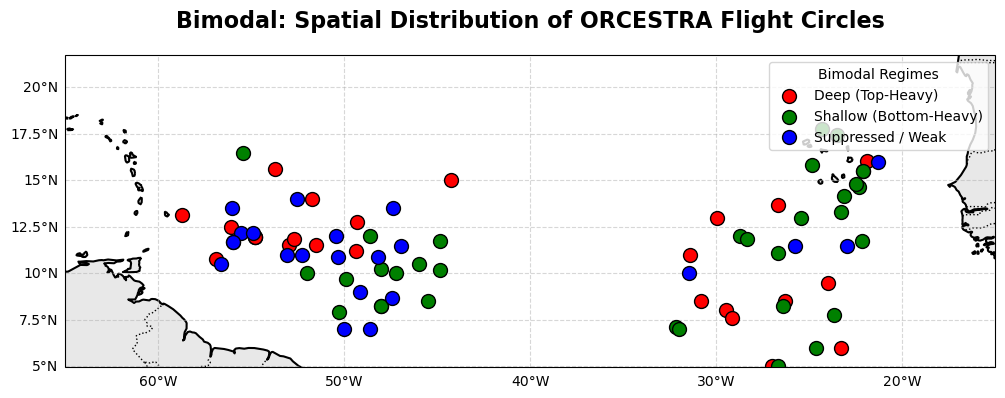


GENERATING BIMODAL INDIVIDUAL DAILY FLIGHT MAPS

Saved: /home/565/zr7147/Proj/Plot-Figs/Bimodal_Geographic_Map_Daily_Grid.png


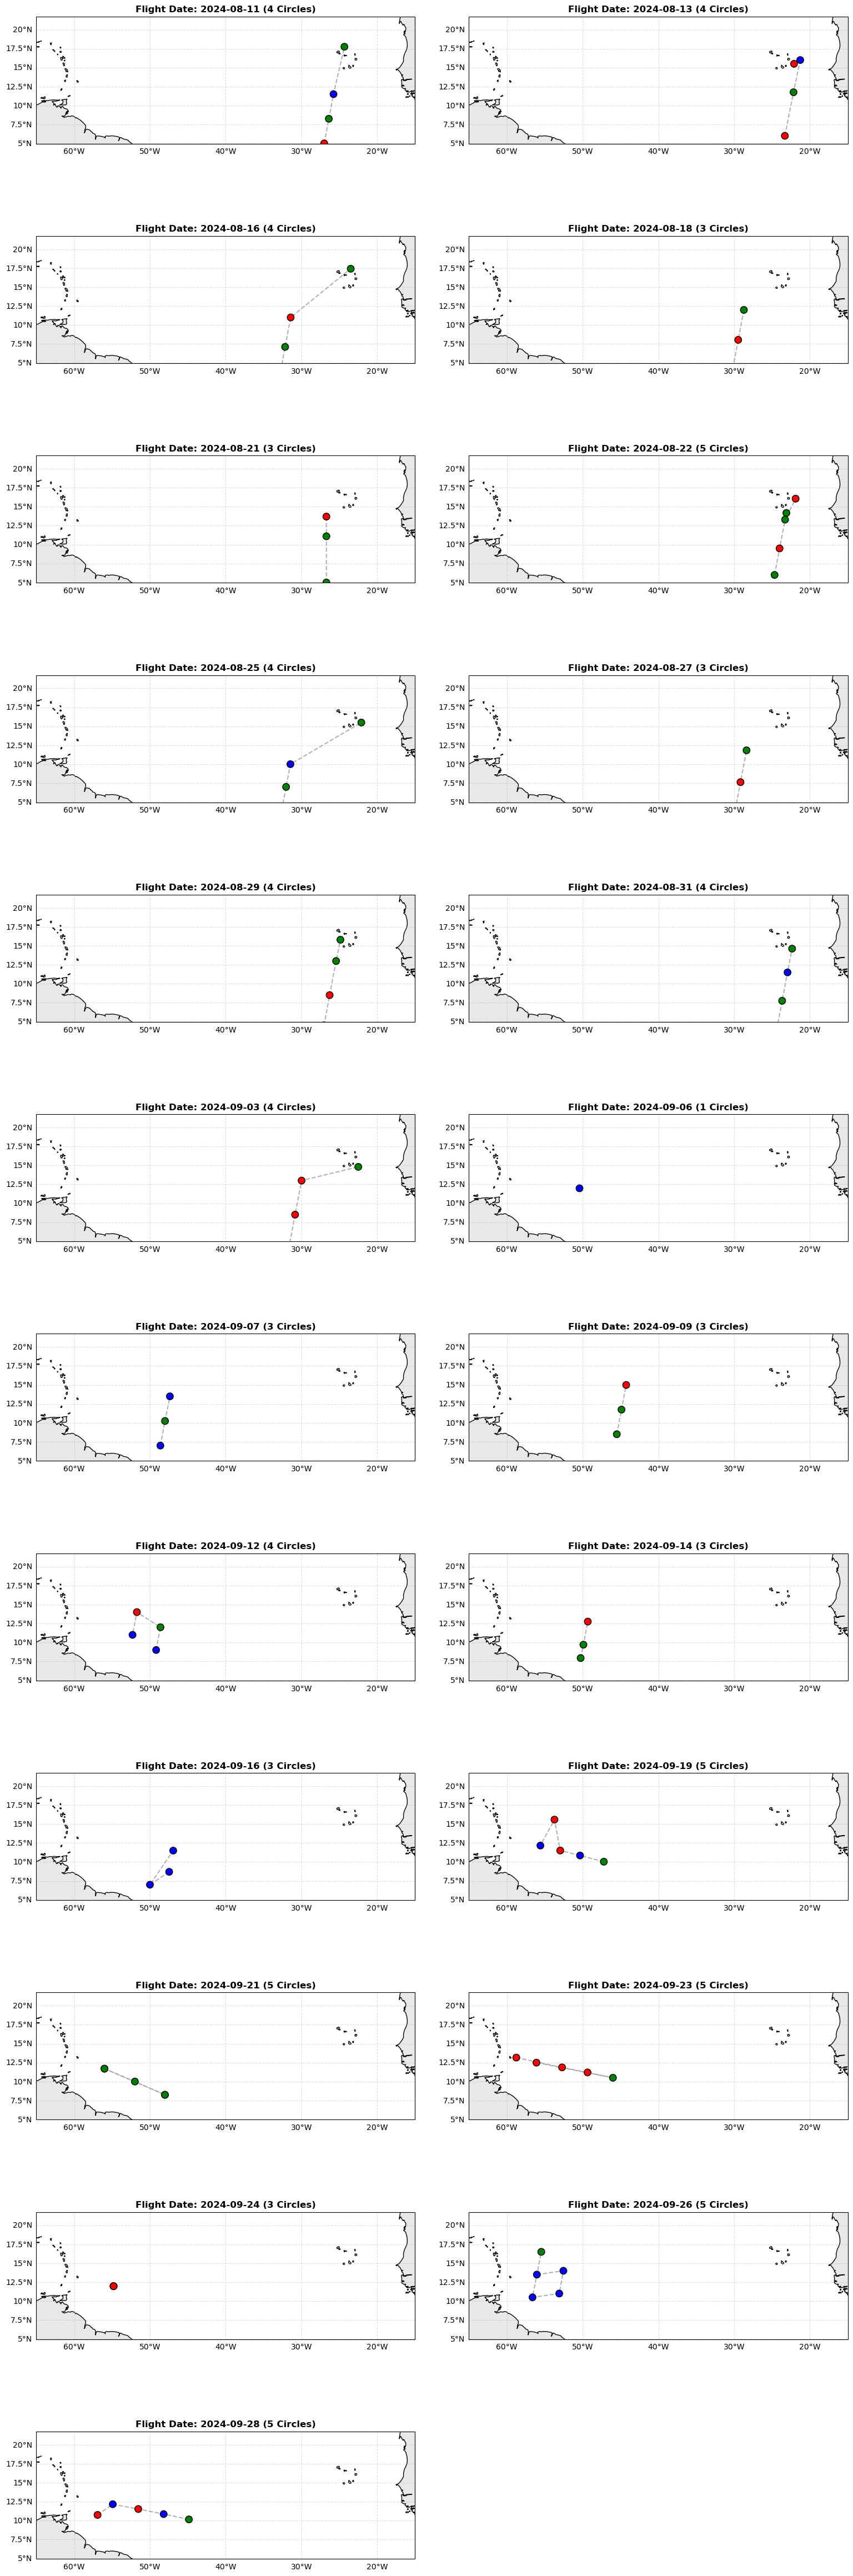

In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
import os

# ---------------------------------------------------------
# 1. SETUP DATA, COLORS, AND MAPPING MODE (TOGGLE HERE)
# ---------------------------------------------------------
output_dir = "/home/565/zr7147/Proj/Plot-Figs"
os.makedirs(output_dir, exist_ok=True) 

# # --- DEFAULT: TRIMODAL MAPPING ---
# mode_prefix = "Trimodal"
# category_var = "category_trimodal"
# regime_mapping = {
#     'Top-Heavy (Deep)': 'red',
#     'Bottom-Heavy (Congestus)': 'orange',
#     'Shallow': 'green',
#     'Suppressed / Weak': 'blue'
# }

#--- ALTERNATIVE: BIMODAL MAPPING ---
# To use this, comment out the block above, and uncomment the block below!
mode_prefix = "Bimodal"
category_var = "category_bimodal"
regime_mapping = {
    'Deep (Top-Heavy)': 'red',
    'Shallow (Bottom-Heavy)': 'green',
    'Suppressed / Weak': 'blue'
}

# Extract all valid data into a clean Pandas DataFrame for easy mapping
map_data = []
for c in ds_categorized.circle.values:
    # Notice we now use [category_var] instead of .category to ensure we grab the right one!
    cat = str(ds_categorized[category_var].sel(circle=c).values)
    
    if cat == "Missing Data":
        continue
        
    lat = ds_categorized['circle_lat'].sel(circle=c).values
    lon = ds_categorized['circle_lon'].sel(circle=c).values
    raw_time = ds_categorized['circle_time'].sel(circle=c).values
    
    dt = pd.to_datetime(raw_time)
    
    map_data.append({
        'circle_id': c,
        'lat': lat,
        'lon': lon,
        'datetime': dt,
        'date': dt.date(), 
        'category': cat,
        'color': regime_mapping.get(cat, 'gray') 
    })

df_map = pd.DataFrame(map_data)
unique_dates = sorted(df_map['date'].unique())

# Set geographic boundaries (Tropical Atlantic)
lon_min, lon_max = -65, -15
lat_min, lat_max = 5, 20

# ---------------------------------------------------------
# PART 2: THE MASTER COMBINED MAP (ALL DATES)
# ---------------------------------------------------------
fig_master = plt.figure(figsize=(12, 6))
ax_master = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax_master.add_feature(cfeature.COASTLINE, linewidth=1.5)
ax_master.add_feature(cfeature.BORDERS, linestyle=':')
ax_master.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
ax_master.set_extent([lon_min, lon_max, lat_min, lat_max])

# Add gridlines
gl = ax_master.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Plot all points
for cat, color in regime_mapping.items():
    subset = df_map[df_map['category'] == cat]
    if not subset.empty:
        ax_master.scatter(subset['lon'], subset['lat'], c=color, s=100, 
                          edgecolor='black', label=cat, transform=ccrs.PlateCarree(), zorder=5)

ax_master.legend(loc='upper right', title=f"{mode_prefix} Regimes")
ax_master.set_title(f'{mode_prefix}: Spatial Distribution of ORCESTRA Flight Circles', fontsize=16, fontweight='bold', pad=20)

# Save Master Map with Mode Prefix
master_path = os.path.join(output_dir, f'{mode_prefix}_Geographic_Map_Combined.png')
fig_master.savefig(master_path, dpi=300, bbox_inches='tight')
print(f"Saved: {master_path}")

plt.show()

# ---------------------------------------------------------
# PART 3: INDIVIDUAL MAPS FOR EACH DATE
# ---------------------------------------------------------
print("\n" + "="*60)
print(f"GENERATING {mode_prefix.upper()} INDIVIDUAL DAILY FLIGHT MAPS")
print("="*60 + "\n")

# Calculate grid size for subplots based on number of unique flight days
cols = 2
rows = math.ceil(len(unique_dates) / cols)

fig_daily = plt.figure(figsize=(cols*8, rows*4))

for i, date in enumerate(unique_dates):
    ax = fig_daily.add_subplot(rows, cols, i+1, projection=ccrs.PlateCarree())
    
    # Map features
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max])
    
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4)
    gl.top_labels = False
    gl.right_labels = False
    
    # Filter data for this specific day
    day_data = df_map[df_map['date'] == date]
    
    # Plot points for this day
    ax.scatter(day_data['lon'], day_data['lat'], c=day_data['color'], s=80, 
               edgecolor='black', transform=ccrs.PlateCarree(), zorder=5)
    
    # Add a dashed line connecting the circles in chronological order to show flight path
    day_data_sorted = day_data.sort_values('datetime')
    ax.plot(day_data_sorted['lon'], day_data_sorted['lat'], color='gray', 
            linestyle='--', alpha=0.6, transform=ccrs.PlateCarree(), zorder=4)
    
    ax.set_title(f'Flight Date: {date} ({len(day_data)} Circles)', fontsize=12, fontweight='bold')

# Clean up empty subplots
#for j in range(i + 1, rows * cols):
#    fig_daily.delaxes(fig_daily.axes[j])

plt.tight_layout(pad=3.0)

# NEW: Save Daily Maps with Mode Prefix
daily_path = os.path.join(output_dir, f'{mode_prefix}_Geographic_Map_Daily_Grid.png')
fig_daily.savefig(daily_path, dpi=300, bbox_inches='tight')
print(f"Saved: {daily_path}")

plt.show()